### Lingchong You
#### 2/14/2026


### Overview of Crosstalk Statistics Aggregation

This notebook computes and aggregates crosstalk statistics across all mixed-inducer and antibiotic datasets into a single supplementary table.

### What the code does

1. **Loads dataset metadata** using `define_metadata()` to access raw fluorescence data and experimental configuration for each community.

2. **Computes crosstalk statistics** using:
   - `mixed_crosstalk_stats()` for non-antibiotic datasets  
   - `antibiotic_crosstalk_stats()` for antibiotic datasets  
  
   These functions are implemented in `crosstalk_with_stats.py`, which is otherwise identical to `crosstalk.py`.  
   The original `crosstalk.py` file is intentionally not modified to maintain backward compatibility with existing analysis pipelines.

   For each dataset, the functions return:
   - `mean` — average normalized crosstalk value  
   - `ci_low`, `ci_high` — 95% bootstrap confidence interval  
   - `sd_boot` — bootstrap standard deviation  
   - replicate counts (`n_off`, `n_on`, or analogous fields)

   Bootstrap resampling is performed over replicate measurements (B = 2000).

3. **Filters the output** to retain only relevant columns:
   - `channel`
   - `inducer_row`
   - `mean`
   - `ci_low`
   - `ci_high`
   - `sd_boot`
   - replicate counts  

   Time-index bookkeeping columns and IQR are excluded.

4. **Concatenates all datasets** into a single master table with a `dataset` identifier.

5. **Exports the master table** in:
   - TSV format 
   - CSV format 
  
Individual datasets are also analyzed individually to ensure consistency.

The reported variability (confidence intervals and SD) reflects well-to-well measurement dispersion within each experimental condition. 


In [12]:
import os
import numpy as np

from data_loading_v5 import define_metadata
from crosstalk_with_stats import mixed_crosstalk, mixed_crosstalk_stats, antibiotic_crosstalk, antibiotic_crosstalk_stats


## Select which community to use and process data

### compute crosstalk statistics for different datasets.

### Statistics for Figure 2. aTC/IPTG.

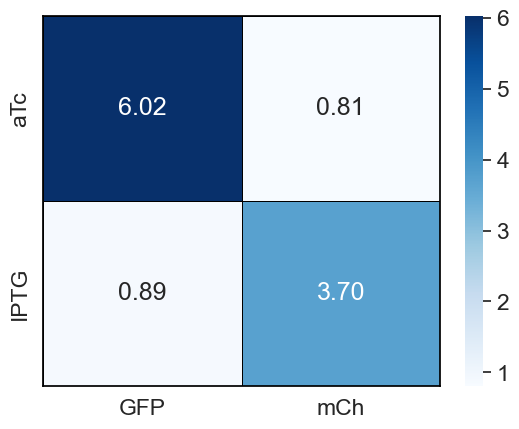

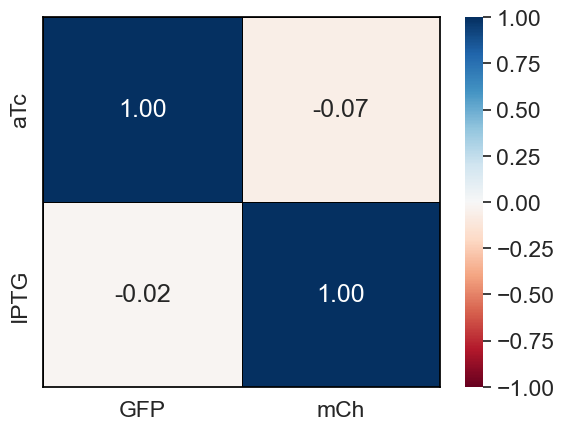

[crosstalk] Saved heatmap to: figures/aTc_IPTG/mixed culture crosstalk.svg
[crosstalk] max |alpha - alpha_stats| = 0.000e+00
[crosstalk] Saved stats table to: figures/aTc_IPTG/mixed_culture_crosstalk_alpha_stats.csv

[crosstalk] Crosstalk alpha statistics (per heatmap cell):
channel inducer_row    mean  sd_boot  iqr_boot  n_off  n_on  timepoint_req_h  timeloc_used
    GFP        IPTG -0.0228   0.0033    0.0046      2     2             20.0           240
    GFP         aTc  1.0000   0.0954    0.1826      2     2             20.0           240
    mCh        IPTG  1.0000   0.0159    0.0323      2     2             20.0           240
    mCh         aTc -0.0698   0.0050    0.0071      2     2             20.0           240


,channel,inducer_row,mean,sd_boot,iqr_boot,n_off,n_on,timepoint_req_h,timeloc_used
1,GFP,IPTG,-0.0228,0.0033,0.0046,2,2,20.0,240
0,GFP,aTc,1.0000,0.0954,0.1826,2,2,20.0,240
3,mCh,IPTG,1.0000,0.0159,0.0323,2,2,20.0,240
2,mCh,aTc,-0.0698,0.0050,0.0071,2,2,20.0,240


In [ ]:
'''crosstalk calculation from mixed culture data + stats printout'''

#select which microbial community dataset to work with
community='aTc_IPTG' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

timepoint = 20  # hours

if community == 'antibiotic_data':
    alphas, fig = antibiotic_crosstalk(timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")

    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")
    print("[crosstalk] NOTE: stats function currently implemented for mixed_crosstalk (non-antibiotic) path.")

else:
    # select file (your existing logic)
    if (community == 'aTc_IPTG') or (community == 'TTR_THS'):
        file = files[0]
    elif community == 'cuma_ohc_atc':
        file = files[2]
    elif (community == 'van_dapg_nar') or (community == 'atc_van'):
        file = files[1]
    else:
        file = files[0]

    # Existing analysis (unchanged)
    alphas, fig = mixed_crosstalk(file, sensors, timepoint, fluors)

    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")
    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")

    # New: stats table
    alphas_stats, stats_df = mixed_crosstalk_stats(
        file_name=file,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=2000
    )

    # sanity check
    max_abs_diff = np.nanmax(np.abs(alphas - alphas_stats))
    print(f"[crosstalk] max |alpha - alpha_stats| = {max_abs_diff:.3e}")

    # Save stats to CSV (as before)
    stats_path = f"{save_dir}mixed_culture_crosstalk_alpha_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"[crosstalk] Saved stats table to: {stats_path}")

    # Round for readability
    pretty_cols = [
        "channel", "inducer_row", "mean",
        "low", "high",
        "sd_boot", "iqr_boot",
        "n_off", "n_on",
        "timepoint_req_h", "timeloc_used"
    ]
    existing_cols = [c for c in pretty_cols if c in stats_df.columns]

    stats_print = stats_df[existing_cols].copy()
    # Optional rounding for display only
    round_cols = ["mean","ci_low","ci_high","sd_boot","iqr_boot"]
    for c in round_cols:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    # Sort to be consistent (channel then inducer)
    if "channel" in stats_print.columns and "inducer_row" in stats_print.columns:
        stats_print = stats_print.sort_values(["channel", "inducer_row"])

    print("\n[crosstalk] Crosstalk alpha statistics (per heatmap cell):")
    print(stats_print.to_string(index=False))

    # Optional: also show as a notebook table (Jupyter pretty display)
    try:
        from IPython.display import display
        display(stats_print)
    except Exception:
        pass


### Figure 3. TTR/THS

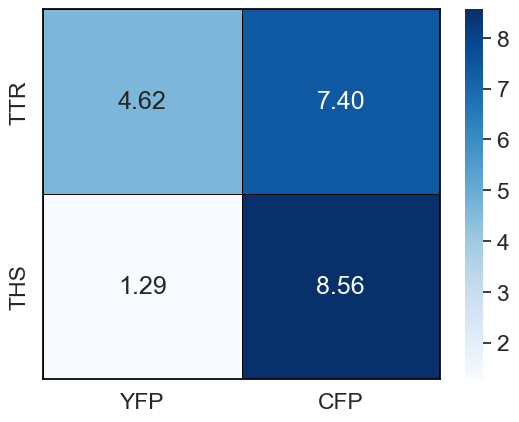

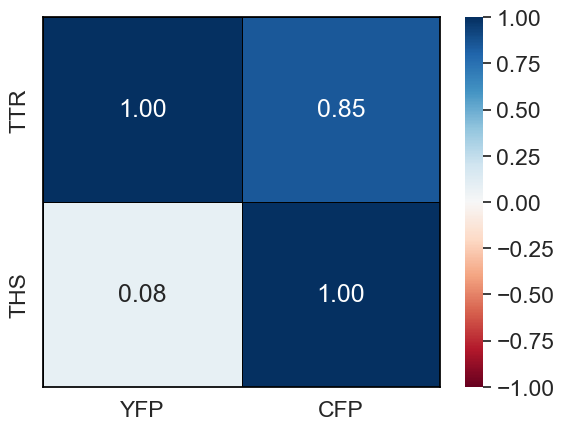

[crosstalk] Saved heatmap to: figures/TTR_THS/mixed culture crosstalk.svg
[crosstalk] max |alpha - alpha_stats| = 0.000e+00
[crosstalk] Saved stats table to: figures/TTR_THS/mixed_culture_crosstalk_alpha_stats.csv

[crosstalk] Crosstalk alpha statistics (per heatmap cell):
channel inducer_row   mean  sd_boot  iqr_boot  n_off  n_on  timepoint_req_h  timeloc_used
    CFP         THS 1.0000   0.0219    0.0444      2     2             20.0           240
    CFP         TTR 0.8466   0.0135    0.0194      2     2             20.0           240
    YFP         THS 0.0796   0.0152    0.0219      2     2             20.0           240
    YFP         TTR 1.0000   0.0088    0.0176      2     2             20.0           240


,channel,inducer_row,mean,sd_boot,iqr_boot,n_off,n_on,timepoint_req_h,timeloc_used
3,CFP,THS,1.0000,0.0219,0.0444,2,2,20.0,240
2,CFP,TTR,0.8466,0.0135,0.0194,2,2,20.0,240
1,YFP,THS,0.0796,0.0152,0.0219,2,2,20.0,240
0,YFP,TTR,1.0000,0.0088,0.0176,2,2,20.0,240


In [ ]:
'''crosstalk calculation from mixed culture data + stats printout'''

#select which microbial community dataset to work with
community='TTR_THS' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

timepoint = 20  # hours

if community == 'antibiotic_data':
    alphas, fig = antibiotic_crosstalk(timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")

    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")
    print("[crosstalk] NOTE: stats function currently implemented for mixed_crosstalk (non-antibiotic) path.")

else:
    # select file (your existing logic)
    if (community == 'aTc_IPTG') or (community == 'TTR_THS'):
        file = files[0]
    elif community == 'cuma_ohc_atc':
        file = files[2]
    elif (community == 'van_dapg_nar') or (community == 'atc_van'):
        file = files[1]
    else:
        file = files[0]

    # Existing analysis (unchanged)
    alphas, fig = mixed_crosstalk(file, sensors, timepoint, fluors)

    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")
    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")

    # New: stats table
    alphas_stats, stats_df = mixed_crosstalk_stats(
        file_name=file,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=2000
    )

    # sanity check
    max_abs_diff = np.nanmax(np.abs(alphas - alphas_stats))
    print(f"[crosstalk] max |alpha - alpha_stats| = {max_abs_diff:.3e}")

    # Save stats to CSV (as before)
    stats_path = f"{save_dir}mixed_culture_crosstalk_alpha_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"[crosstalk] Saved stats table to: {stats_path}")

    # Round for readability
    pretty_cols = [
        "channel", "inducer_row", "mean",
        "low", "high",
        "sd_boot", "iqr_boot",
        "n_off", "n_on",
        "timepoint_req_h", "timeloc_used"
    ]
    existing_cols = [c for c in pretty_cols if c in stats_df.columns]

    stats_print = stats_df[existing_cols].copy()
    # Optional rounding for display only
    round_cols = ["mean","ci_low","ci_high","sd_boot","iqr_boot"]
    for c in round_cols:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    # Sort to be consistent (channel then inducer)
    if "channel" in stats_print.columns and "inducer_row" in stats_print.columns:
        stats_print = stats_print.sort_values(["channel", "inducer_row"])

    print("\n[crosstalk] Crosstalk alpha statistics (per heatmap cell):")
    print(stats_print.to_string(index=False))

    # Optional: also show as a notebook table (Jupyter pretty display)
    try:
        from IPython.display import display
        display(stats_print)
    except Exception:
        pass


### Figure 4ab, CUMA/OHC/ATC

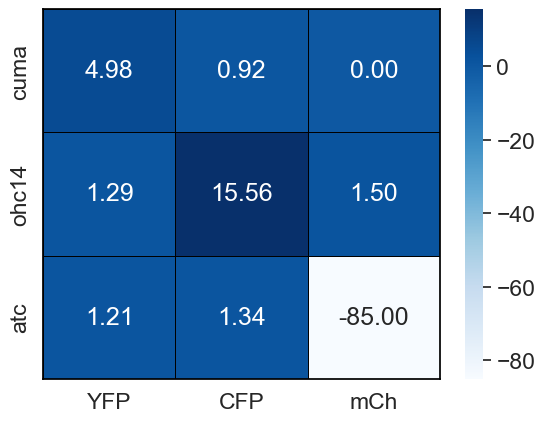

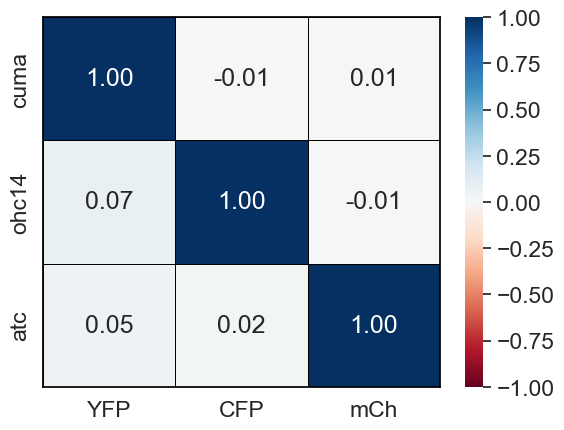

[crosstalk] Saved heatmap to: figures/cuma_ohc_atc/mixed culture crosstalk.svg
[crosstalk] max |alpha - alpha_stats| = 0.000e+00
[crosstalk] Saved stats table to: figures/cuma_ohc_atc/mixed_culture_crosstalk_alpha_stats.csv

[crosstalk] Crosstalk alpha statistics (per heatmap cell):
channel inducer_row    mean  sd_boot  iqr_boot  n_off  n_on  timepoint_req_h  timeloc_used
    CFP         atc  0.0235   0.0027    0.0034      2     2             20.0           231
    CFP        cuma -0.0053   0.0014    0.0006      2     2             20.0           231
    CFP       ohc14  1.0000   0.0532    0.1058      2     2             20.0           231
    YFP         atc  0.0528   0.0090    0.0131      2     2             20.0           231
    YFP        cuma  1.0000   0.0399    0.0788      2     2             20.0           231
    YFP       ohc14  0.0729   0.0056    0.0072      2     2             20.0           231
    mCh         atc  1.0000   0.0000    0.0000      2     2             20.0   

,channel,inducer_row,mean,sd_boot,iqr_boot,n_off,n_on,timepoint_req_h,timeloc_used
5,CFP,atc,0.0235,0.0027,0.0034,2,2,20.0,231
3,CFP,cuma,-0.0053,0.0014,0.0006,2,2,20.0,231
4,CFP,ohc14,1.0000,0.0532,0.1058,2,2,20.0,231
2,YFP,atc,0.0528,0.0090,0.0131,2,2,20.0,231
0,YFP,cuma,1.0000,0.0399,0.0788,2,2,20.0,231
1,YFP,ohc14,0.0729,0.0056,0.0072,2,2,20.0,231
8,mCh,atc,1.0000,0.0000,0.0000,2,2,20.0,231
6,mCh,cuma,0.0116,0.0083,0.0116,2,2,20.0,231
7,mCh,ohc14,-0.0058,0.0121,0.0174,2,2,20.0,231


In [ ]:
'''crosstalk calculation from mixed culture data + stats printout'''

#select which microbial community dataset to work with
community='cuma_ohc_atc' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

timepoint = 20  # hours

if community == 'antibiotic_data':
    alphas, fig = antibiotic_crosstalk(timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")

    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")
    print("[crosstalk] NOTE: stats function currently implemented for mixed_crosstalk (non-antibiotic) path.")

else:
    # select file (your existing logic)
    if (community == 'aTc_IPTG') or (community == 'TTR_THS'):
        file = files[0]
    elif community == 'cuma_ohc_atc':
        file = files[2]
    elif (community == 'van_dapg_nar') or (community == 'atc_van'):
        file = files[1]
    else:
        file = files[0]

    # Existing analysis (unchanged)
    alphas, fig = mixed_crosstalk(file, sensors, timepoint, fluors)

    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")
    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")

    # New: stats table
    alphas_stats, stats_df = mixed_crosstalk_stats(
        file_name=file,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=2000
    )

    # sanity check
    max_abs_diff = np.nanmax(np.abs(alphas - alphas_stats))
    print(f"[crosstalk] max |alpha - alpha_stats| = {max_abs_diff:.3e}")

    # Save stats to CSV (as before)
    stats_path = f"{save_dir}mixed_culture_crosstalk_alpha_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"[crosstalk] Saved stats table to: {stats_path}")

    # Round for readability
    pretty_cols = [
        "channel", "inducer_row", "mean",
        "low", "high",
        "sd_boot", "iqr_boot",
        "n_off", "n_on",
        "timepoint_req_h", "timeloc_used"
    ]
    existing_cols = [c for c in pretty_cols if c in stats_df.columns]

    stats_print = stats_df[existing_cols].copy()
    # Optional rounding for display only
    round_cols = ["mean","ci_low","ci_high","sd_boot","iqr_boot"]
    for c in round_cols:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    # Sort to be consistent (channel then inducer)
    if "channel" in stats_print.columns and "inducer_row" in stats_print.columns:
        stats_print = stats_print.sort_values(["channel", "inducer_row"])

    print("\n[crosstalk] Crosstalk alpha statistics (per heatmap cell):")
    print(stats_print.to_string(index=False))

    # Optional: also show as a notebook table (Jupyter pretty display)
    try:
        from IPython.display import display
        display(stats_print)
    except Exception:
        pass


### Figure 4C,D VAN/NAR/DAPG

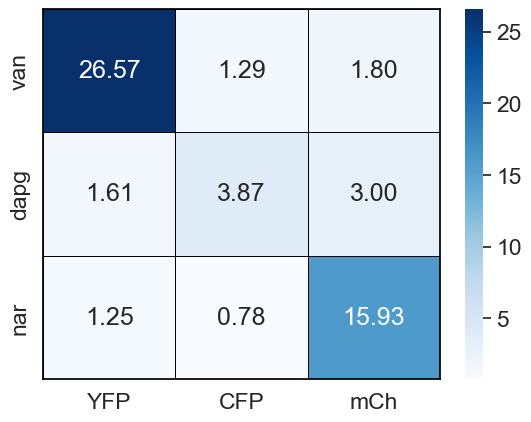

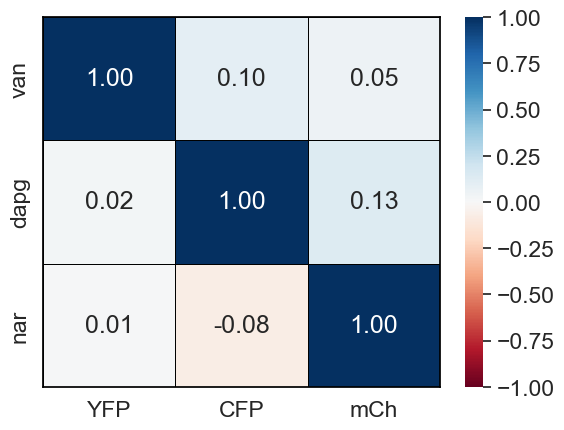

[crosstalk] Saved heatmap to: figures/van_dapg_nar/mixed culture crosstalk.svg
[crosstalk] max |alpha - alpha_stats| = 0.000e+00
[crosstalk] Saved stats table to: figures/van_dapg_nar/mixed_culture_crosstalk_alpha_stats.csv

[crosstalk] Crosstalk alpha statistics (per heatmap cell):
channel inducer_row    mean  sd_boot  iqr_boot  n_off  n_on  timepoint_req_h  timeloc_used
    CFP        dapg  1.0000   0.0468    0.0709      3     3             20.0           240
    CFP         nar -0.0767   0.0109    0.0173      3     3             20.0           240
    CFP         van  0.1007   0.0053    0.0072      3     3             20.0           240
    YFP        dapg  0.0240   0.0006    0.0010      3     3             20.0           240
    YFP         nar  0.0096   0.0015    0.0021      3     3             20.0           240
    YFP         van  1.0000   0.0265    0.0361      3     3             20.0           240
    mCh        dapg  0.1339   0.0069    0.0099      3     3             20.0   

,channel,inducer_row,mean,sd_boot,iqr_boot,n_off,n_on,timepoint_req_h,timeloc_used
4,CFP,dapg,1.0000,0.0468,0.0709,3,3,20.0,240
5,CFP,nar,-0.0767,0.0109,0.0173,3,3,20.0,240
3,CFP,van,0.1007,0.0053,0.0072,3,3,20.0,240
1,YFP,dapg,0.0240,0.0006,0.0010,3,3,20.0,240
2,YFP,nar,0.0096,0.0015,0.0021,3,3,20.0,240
0,YFP,van,1.0000,0.0265,0.0361,3,3,20.0,240
7,mCh,dapg,0.1339,0.0069,0.0099,3,3,20.0,240
8,mCh,nar,1.0000,0.0739,0.1102,3,3,20.0,240
6,mCh,van,0.0536,0.0132,0.0179,3,3,20.0,240


In [ ]:
'''crosstalk calculation from mixed culture data + stats printout'''

#select which microbial community dataset to work with
community='van_dapg_nar' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

timepoint = 20  # hours

if community == 'antibiotic_data':
    alphas, fig = antibiotic_crosstalk(timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")

    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")
    print("[crosstalk] NOTE: stats function currently implemented for mixed_crosstalk (non-antibiotic) path.")

else:
    # select file (your existing logic)
    if (community == 'aTc_IPTG') or (community == 'TTR_THS'):
        file = files[0]
    elif community == 'cuma_ohc_atc':
        file = files[2]
    elif (community == 'van_dapg_nar') or (community == 'atc_van'):
        file = files[1]
    else:
        file = files[0]

    # Existing analysis (unchanged)
    alphas, fig = mixed_crosstalk(file, sensors, timepoint, fluors)

    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")
    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")

    # New: stats table
    alphas_stats, stats_df = mixed_crosstalk_stats(
        file_name=file,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=2000
    )

    # sanity check
    max_abs_diff = np.nanmax(np.abs(alphas - alphas_stats))
    print(f"[crosstalk] max |alpha - alpha_stats| = {max_abs_diff:.3e}")

    # Save stats to CSV (as before)
    stats_path = f"{save_dir}mixed_culture_crosstalk_alpha_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"[crosstalk] Saved stats table to: {stats_path}")

    # Round for readability
    pretty_cols = [
        "channel", "inducer_row", "mean",
        "low", "high",
        "sd_boot", "iqr_boot",
        "n_off", "n_on",
        "timepoint_req_h", "timeloc_used"
    ]
    existing_cols = [c for c in pretty_cols if c in stats_df.columns]

    stats_print = stats_df[existing_cols].copy()
    # Optional rounding for display only
    round_cols = ["mean","ci_low","ci_high","sd_boot","iqr_boot"]
    for c in round_cols:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    # Sort to be consistent (channel then inducer)
    if "channel" in stats_print.columns and "inducer_row" in stats_print.columns:
        stats_print = stats_print.sort_values(["channel", "inducer_row"])

    print("\n[crosstalk] Crosstalk alpha statistics (per heatmap cell):")
    print(stats_print.to_string(index=False))

    # Optional: also show as a notebook table (Jupyter pretty display)
    try:
        from IPython.display import display
        display(stats_print)
    except Exception:
        pass


### Figure 5bd. HSGBla/TAZ

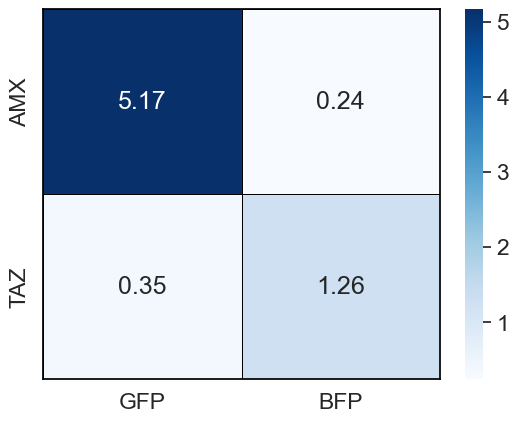

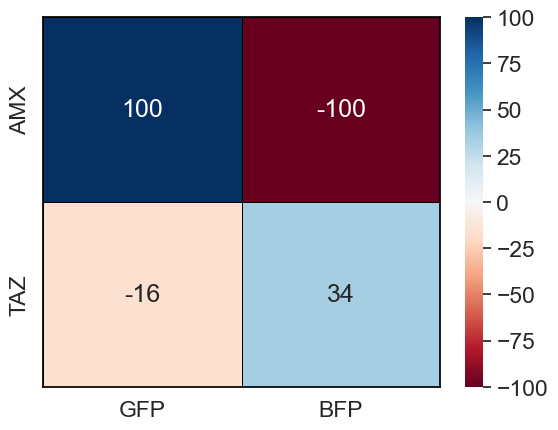

channel inducer_row    mean  ci_low  ci_high  sd_boot  iqr_boot  n_Amax  n_Imax  timepoint_req_h  timeloc_used
    BFP         AMX -1.0000 -1.0000  -1.0000   0.0000    0.0000       3       3             20.0           120
    BFP         TAZ  0.3422  0.2274   0.4525   0.0561    0.0751       3       3             20.0           120
    GFP         AMX  1.0000  1.0000   1.0000   0.0000    0.0000       3       3             20.0           120
    GFP         TAZ -0.1567 -0.1674  -0.1482   0.0049    0.0071       3       3             20.0           120


In [6]:
#select which microbial community dataset to work with
community='antibiotic_data' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)


if community=='antibiotic_data':
    alphas,fig = antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

    # NEW: stats
    alphas_stats, stats_df = antibiotic_crosstalk_stats(
        timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors, n_boot=2000
    )

    # print + save
    stats_print = stats_df.sort_values(["channel", "inducer_row"]).copy()
    for c in ["mean","ci_low","ci_high","sd_boot","iqr_boot"]:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    print(stats_print.to_string(index=False))
    stats_print.to_csv(f"{save_dir}antibiotic_crosstalk_alpha_stats.csv", index=False)


### Figure5ce, HSGBla/Sul

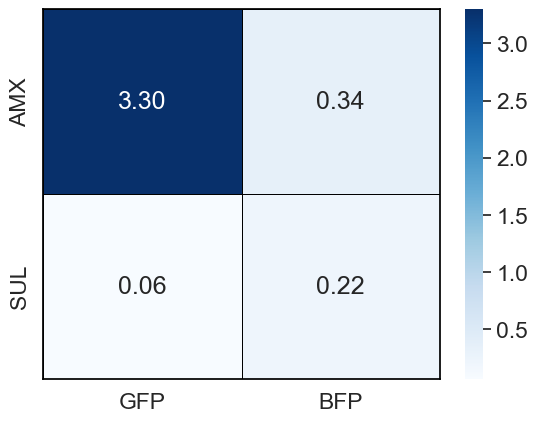

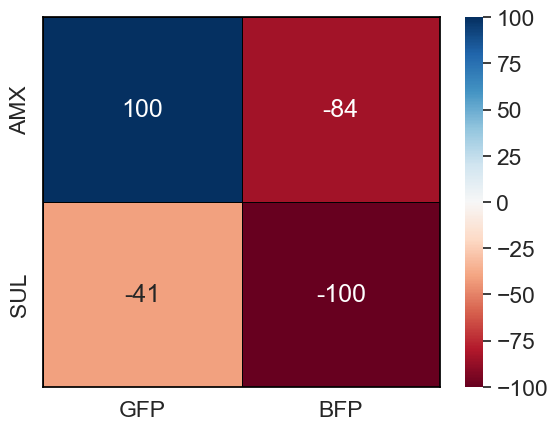

channel inducer_row    mean  ci_low  ci_high  sd_boot  iqr_boot  n_Amax  n_Imax  timepoint_req_h  timeloc_used
    BFP         AMX -0.8413 -0.9736  -0.7278   0.0668    0.0995       3       3             20.0           120
    BFP         SUL -1.0000 -1.0000  -1.0000   0.0053    0.0000       3       3             20.0           120
    GFP         AMX  1.0000  1.0000   1.0000   0.0000    0.0000       3       3             20.0           120
    GFP         SUL -0.4070 -0.4355  -0.3806   0.0130    0.0187       3       3             20.0           120


In [7]:
#select which microbial community dataset to work with
community='antibiotic_data' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='SUL' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)


if community=='antibiotic_data':
    alphas,fig = antibiotic_crosstalk(timepoint,time_vector,files,od_raws,fp1_raws,fp2_raws,fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f'{save_dir}mixed culture crosstalk.svg',format='svg')

    # NEW: stats
    alphas_stats, stats_df = antibiotic_crosstalk_stats(
        timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors, n_boot=2000
    )

    # print + save
    stats_print = stats_df.sort_values(["channel", "inducer_row"]).copy()
    for c in ["mean","ci_low","ci_high","sd_boot","iqr_boot"]:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    print(stats_print.to_string(index=False))
    stats_print.to_csv(f"{save_dir}antibiotic_crosstalk_alpha_stats.csv", index=False)


### Figure 6 Sink Water


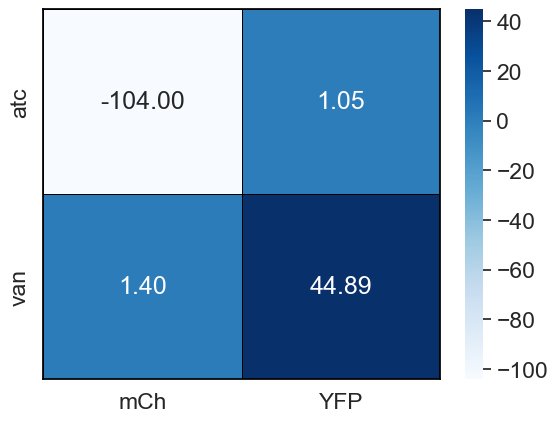

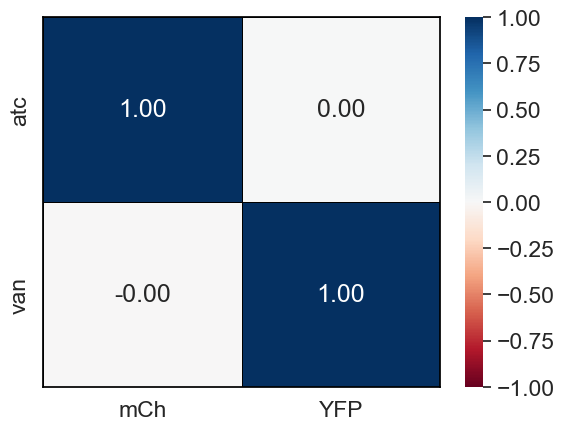

[crosstalk] Saved heatmap to: figures/atc_van/mixed culture crosstalk.svg
[crosstalk] max |alpha - alpha_stats| = 0.000e+00
[crosstalk] Saved stats table to: figures/atc_van/mixed_culture_crosstalk_alpha_stats.csv

[crosstalk] Crosstalk alpha statistics (per heatmap cell):
channel inducer_row    mean  sd_boot  iqr_boot  n_off  n_on  timepoint_req_h  timeloc_used
    YFP         atc  0.0012   0.0003    0.0004      2     2             20.0           240
    YFP         van  1.0000   0.0888    0.1732      2     2             20.0           240
    mCh         atc  1.0000   0.0644    0.1256      2     2             20.0           240
    mCh         van -0.0038   0.0013    0.0018      2     2             20.0           240


,channel,inducer_row,mean,sd_boot,iqr_boot,n_off,n_on,timepoint_req_h,timeloc_used
2,YFP,atc,0.0012,0.0003,0.0004,2,2,20.0,240
3,YFP,van,1.0000,0.0888,0.1732,2,2,20.0,240
0,mCh,atc,1.0000,0.0644,0.1256,2,2,20.0,240
1,mCh,van,-0.0038,0.0013,0.0018,2,2,20.0,240


In [ ]:
'''crosstalk calculation from mixed culture data + stats printout'''

#select which microbial community dataset to work with
community='atc_van' #list of options: 'aTc_IPTG','TTR_THS','cuma_ohc_atc','van_dapg_nar', 'antibiotic_data','atc_van', 'ttr_ths_ph'

#if using antibiotic data, indicate the plasmid and inhibitor combination
plasmid='HSGBla' #options: 'Bla', 'BlaM', 'HSGBla', 'HSGBlaM'
inhibitor='TAZ' #options: 'TAZ', 'SUL'
if community!='antibiotic_data':
    plasmid=None
    inhibitor=None

#import metadata for selected community
files,readers, fluors, fluor1, fluor2, fluor3, single_file, sensor_names, sensors,time_vector,od_raws,input_arrays,input_names,fp1_raws,fp2_raws,fp3_raws = define_metadata(community,plasmid,inhibitor)

timepoint = 20  # hours

if community == 'antibiotic_data':
    alphas, fig = antibiotic_crosstalk(timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors)

    save_dir = f"figures/{community}/{plasmid}_{inhibitor}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")

    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")
    print("[crosstalk] NOTE: stats function currently implemented for mixed_crosstalk (non-antibiotic) path.")

else:
    # select file (your existing logic)
    if (community == 'aTc_IPTG') or (community == 'TTR_THS'):
        file = files[0]
    elif community == 'cuma_ohc_atc':
        file = files[2]
    elif (community == 'van_dapg_nar') or (community == 'atc_van'):
        file = files[1]
    else:
        file = files[0]

    # Existing analysis (unchanged)
    alphas, fig = mixed_crosstalk(file, sensors, timepoint, fluors)

    save_dir = f"figures/{community}/"
    os.makedirs(save_dir, exist_ok=True)
    fig.savefig(f"{save_dir}mixed culture crosstalk.svg", format="svg")
    print(f"[crosstalk] Saved heatmap to: {save_dir}mixed culture crosstalk.svg")

    # New: stats table
    alphas_stats, stats_df = mixed_crosstalk_stats(
        file_name=file,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=2000
    )

    # sanity check
    max_abs_diff = np.nanmax(np.abs(alphas - alphas_stats))
    print(f"[crosstalk] max |alpha - alpha_stats| = {max_abs_diff:.3e}")

    # Save stats to CSV (as before)
    stats_path = f"{save_dir}mixed_culture_crosstalk_alpha_stats.csv"
    stats_df.to_csv(stats_path, index=False)
    print(f"[crosstalk] Saved stats table to: {stats_path}")

    # Round for readability
    pretty_cols = [
        "channel", "inducer_row", "mean",
        "low", "high",
        "sd_boot", "iqr_boot",
        "n_off", "n_on",
        "timepoint_req_h", "timeloc_used"
    ]
    existing_cols = [c for c in pretty_cols if c in stats_df.columns]

    stats_print = stats_df[existing_cols].copy()
    # Optional rounding for display only
    round_cols = ["mean","ci_low","ci_high","sd_boot","iqr_boot"]
    for c in round_cols:
        if c in stats_print.columns:
            stats_print[c] = stats_print[c].astype(float).round(4)

    # Sort to be consistent (channel then inducer)
    if "channel" in stats_print.columns and "inducer_row" in stats_print.columns:
        stats_print = stats_print.sort_values(["channel", "inducer_row"])

    print("\n[crosstalk] Crosstalk alpha statistics (per heatmap cell):")
    print(stats_print.to_string(index=False))

    # Optional: also show as a notebook table (Jupyter pretty display)
    try:
        from IPython.display import display
        display(stats_print)
    except Exception:
        pass


### Generate a combined table for all these datasets and save in a .csv file

In [10]:
import os
import pandas as pd

from data_loading_v5 import define_metadata
from crosstalk_with_stats import mixed_crosstalk_stats, antibiotic_crosstalk_stats

# ----------------------------
# User choices
# ----------------------------
N_BOOT = 2000
DEFAULT_TIMEPOINT_H = 20

MIXED_COMMUNITIES = [
    "aTc_IPTG",
    "TTR_THS",
    "cuma_ohc_atc",
    "van_dapg_nar",
    "atc_van",
    "ttr_ths_ph",
]

ABX_COMMUNITY = "antibiotic_data"
PLASMIDS  = ["Bla", "BlaM", "HSGBla", "HSGBlaM"]
INHIBITORS = ["TAZ", "SUL"]

COMMUNITY_FILE_INDEX = {
    "aTc_IPTG": 0,
    "TTR_THS": 0,
    "cuma_ohc_atc": 2,
    "van_dapg_nar": 1,
    "atc_van": 1,
    "ttr_ths_ph": 0,
}

OUTDIR = "supp_tables"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------
# Helper
# ----------------------------
def _standardize(df: pd.DataFrame, dataset_id: str) -> pd.DataFrame:
    """
    Keep only:
      dataset,
      channel,
      inducer_row,
      mean,
      ci_low,
      ci_high,
      sd_boot,
      replicate columns (whatever they are named)
    Drop everything else.
    """

    # Required stat columns (must already exist)
    required_stats = ["channel", "inducer_row", "mean", "ci_low", "ci_high", "sd_boot"]

    missing = [c for c in required_stats if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}\nAvailable: {list(df.columns)}")

    keep = required_stats.copy()

    # Keep replicate columns exactly as they exist
    replicate_candidates = ["n_off", "n_on", "n_Amax", "n_Imax"]
    for c in replicate_candidates:
        if c in df.columns:
            keep.append(c)

    out = df[keep].copy()
    out.insert(0, "dataset", dataset_id)

    # Round numeric stats for cleaner Word table
    for c in ["mean", "ci_low", "ci_high", "sd_boot"]:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(4)

    return out.sort_values(["dataset", "channel", "inducer_row"]).reset_index(drop=True)

# ----------------------------
# Main loop
# ----------------------------
all_tables = []

# ---- Mixed datasets ----
for community in MIXED_COMMUNITIES:
    plasmid = None
    inhibitor = None

    (files, readers, fluors, fluor1, fluor2, fluor3, single_file,
     sensor_names, sensors, time_vector, od_raws, input_arrays,
     input_names, fp1_raws, fp2_raws, fp3_raws) = define_metadata(community, plasmid, inhibitor)

    file_idx = COMMUNITY_FILE_INDEX.get(community, 0)
    file_name = files[file_idx]
    timepoint = DEFAULT_TIMEPOINT_H

    _, stats_df = mixed_crosstalk_stats(
        file_name=file_name,
        sensors=sensors,
        timepoint=timepoint,
        fluors=fluors,
        n_boot=N_BOOT
    )

    all_tables.append(_standardize(stats_df, community))

# ---- Antibiotic datasets ----
for plasmid in PLASMIDS:
    for inhibitor in INHIBITORS:
        community = ABX_COMMUNITY

        (files, readers, fluors, fluor1, fluor2, fluor3, single_file,
         sensor_names, sensors, time_vector, od_raws, input_arrays,
         input_names, fp1_raws, fp2_raws, fp3_raws) = define_metadata(community, plasmid, inhibitor)

        timepoint = DEFAULT_TIMEPOINT_H

        _, stats_df = antibiotic_crosstalk_stats(
            timepoint, time_vector, files, od_raws, fp1_raws, fp2_raws, fluors,
            n_boot=N_BOOT
        )

        dataset_id = f"{community}__{plasmid}_{inhibitor}"
        all_tables.append(_standardize(stats_df, dataset_id))

# Concatenate all
master = pd.concat(all_tables, ignore_index=True)

# Save TSV (best for Word conversion)
tsv_path = os.path.join(OUTDIR, "Supplementary_Table_Crosstalk.tsv")
master.to_csv(tsv_path, sep="\t", index=False)

# Save CSV (Excel-friendly)
csv_path = os.path.join(OUTDIR, "Supplementary_Table_Crosstalk.csv")
master.to_csv(csv_path, index=False)

print(f"[OK] TSV written: {tsv_path}")
print(f"[OK] CSV written: {csv_path}")
print(master.head(10).to_string(index=False))

# Optional DOCX export
try:
    from docx import Document

    doc = Document()
    doc.add_heading("Supplementary Table: Crosstalk statistics", level=1)
    doc.add_paragraph(
        "Entries report mean, bootstrap SD (sd_boot), and 95% bootstrap confidence interval "
        "(ci_low, ci_high) computed from replicate wells."
    )

    table = doc.add_table(rows=1, cols=len(master.columns))
    for j, col in enumerate(master.columns):
        table.rows[0].cells[j].text = str(col)

    for _, row in master.iterrows():
        cells = table.add_row().cells
        for j, col in enumerate(master.columns):
            val = row[col]
            cells[j].text = "" if pd.isna(val) else str(val)

    docx_path = os.path.join(OUTDIR, "Supplementary_Table_Crosstalk.docx")
    doc.save(docx_path)
    print(f"[OK] DOCX written: {docx_path}")

except Exception as e:
    print("[WARN] Could not write DOCX. TSV/CSV still available.")
    print("       Error:", repr(e))


[OK] TSV written: supp_tables/Supplementary_Table_Crosstalk.tsv
[OK] CSV written: supp_tables/Supplementary_Table_Crosstalk.csv
     dataset channel inducer_row    mean  ci_low  ci_high  sd_boot  n_off  n_on  n_Amax  n_Imax
    aTc_IPTG     GFP        IPTG -0.0228 -0.0298  -0.0170   0.0033    2.0   2.0     NaN     NaN
    aTc_IPTG     GFP         aTc  1.0000  0.8258   1.2110   0.0954    2.0   2.0     NaN     NaN
    aTc_IPTG     mCh        IPTG  1.0000  0.9680   1.0331   0.0159    2.0   2.0     NaN     NaN
    aTc_IPTG     mCh         aTc -0.0698 -0.0780  -0.0618   0.0050    2.0   2.0     NaN     NaN
     TTR_THS     CFP         THS  1.0000  0.9561   1.0459   0.0219    2.0   2.0     NaN     NaN
     TTR_THS     CFP         TTR  0.8466  0.8259   0.8683   0.0135    2.0   2.0     NaN     NaN
     TTR_THS     YFP         THS  0.0796  0.0570   0.1027   0.0152    2.0   2.0     NaN     NaN
     TTR_THS     YFP         TTR  1.0000  0.9825   1.0179   0.0088    2.0   2.0     NaN     NaN
cuma_ohc